In [39]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
df = pd.read_excel("final_features.xlsx")

### filtering the dataframe to only use the necessary coloumns

In [29]:

required_cols = [
    "state",
    "date",
    "REI",
    "Population_actual"
]


df_filtered = df[required_cols].copy()
df_filtered.reset_index(drop=True, inplace=True)


print("Filtered dataframe:")

print("\n Columns:")
print(df_filtered.columns)

print("\n Shape:")
print(df_filtered.shape)

print("\n Sample data:")
print(df_filtered.head())

Filtered dataframe:

 Columns:
Index(['state', 'date', 'REI', 'Population_actual'], dtype='object')

 Shape:
(1352, 4)

 Sample data:
            state       date           REI  Population_actual
0  andhra pradesh 2021-02-14  2.828644e+07           52787000
1  andhra pradesh 2021-02-21  2.932608e+07           52787000
2  andhra pradesh 2021-02-28  2.771001e+07           52787000
3  andhra pradesh 2021-03-07  9.696444e+06           52787000
4  andhra pradesh 2021-03-14  2.068986e+07           52787000



 2021 VALIDATION:
MAE: 2.383
R²: 0.959


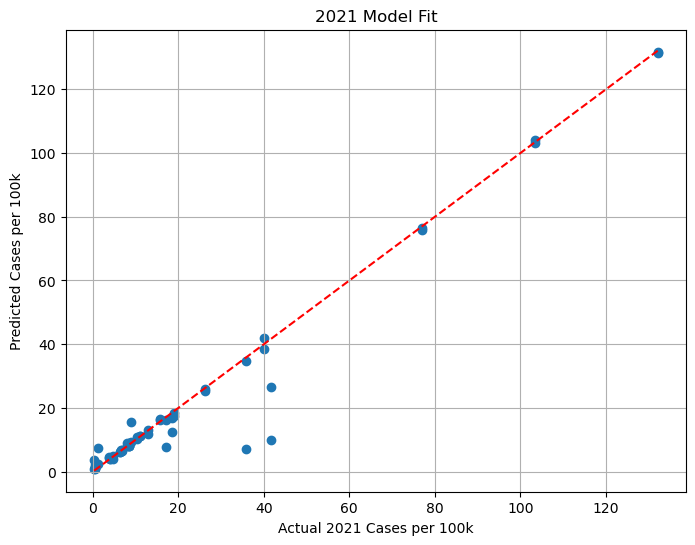


 2022 VALIDATION:
MAE: 17.108
R²: 0.008


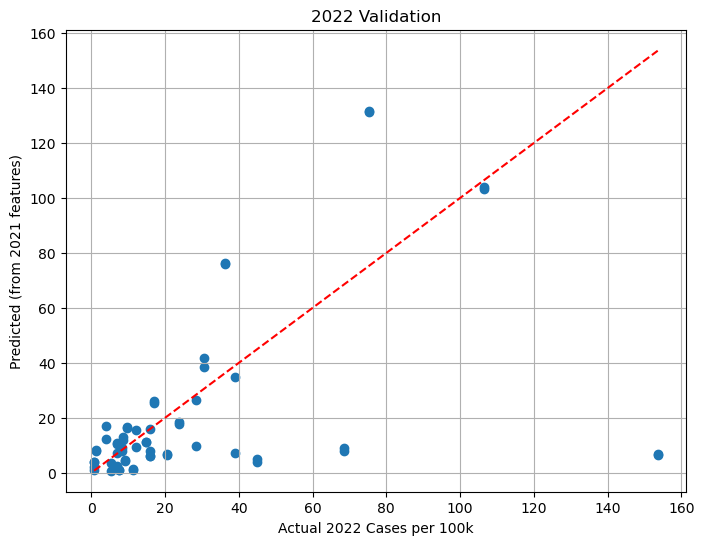

In [60]:

df["state"] = df["state"].str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

#aggregating data to obtain yearly values instead of weekly, so we can compare with data from other years
df_annual = df.groupby(["state", "year"]).agg({
    "weekly_avg_rainfall": "sum",
    "REI": "sum",
    "DWE": "mean",
    "REI_norm": "mean",
    "Population_Density": "first",
    "infra_risk": "first",
    "urban_pct": "first",
    "sanitation_risk": "first",
    "water_risk": "first",
    "Population_actual": "first"
}).reset_index()


states = [
    "andhra pradesh","arunachal pradesh","assam","bihar","chhattisgarh","goa",
    "gujarat","haryana","himachal pradesh","jharkhand","karnataka",
    "kerala","madhya pradesh","meghalaya","maharashtra",
    "manipur","mizoram","nagaland","odisha","punjab","rajasthan","sikkim",
    "tamil nadu","tripura","telangana","uttar pradesh","uttarakhand",
    "west bengal","chandigarh","puducherry"
]

cases_2021 = [
    4760,7,103,633,1086,649,10983,11835,349,220,7393,3251,
    15592,129,12720,203,83,24,7548,23389,20749,243,6039,349,7135,
    29750,738,8264,1596,1625
]

df_cases_2021 = pd.DataFrame({
    "state": states,
    "cases_2021": cases_2021
})

df_cases_2021["state"] = df_cases_2021["state"].str.lower().str.strip()

df_annual = df_annual.merge(df_cases_2021, on="state", how="left")


df_annual["cases_per_100k"] = (
    df_annual["cases_2021"] / df_annual["Population_actual"]
) * 100000

# removing NaN and infinity values
df_annual = df_annual.replace([np.inf, -np.inf], np.nan)
df_annual = df_annual.dropna()

# print(df_annual.shape) #verifying dataset shape after cleaning

TARGET = "cases_per_100k"

features = [
    "weekly_avg_rainfall",
    "REI",
    "DWE",
    "REI_norm",
    "Population_Density",
    "infra_risk",
    "urban_pct",
    "sanitation_risk",
    "water_risk"
]

X = df_annual[features]
y = df_annual[TARGET]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)



df_annual["predicted_2021"] = model.predict(X)

mae_1 = mean_absolute_error(
    df_annual["cases_per_100k"],
    df_annual["predicted_2021"]
)

r2_1 = r2_score(
    df_annual["cases_per_100k"],
    df_annual["predicted_2021"]
)
print("\n 2021 VALIDATION:")
print("MAE:", round(mae_1, 3))
print("R²:", round(r2_1, 3))



plt.figure(figsize=(8,6))
plt.scatter(
    df_annual["cases_per_100k"],
    df_annual["predicted_2021"]
)

plt.xlabel("Actual 2021 Cases per 100k")
plt.ylabel("Predicted Cases per 100k")
plt.title("2021 Model Fit")

plt.plot(
    [df_annual["cases_per_100k"].min(), df_annual["cases_per_100k"].max()],
    [df_annual["cases_per_100k"].min(), df_annual["cases_per_100k"].max()],
    'r--'
)
plt.savefig('2021cases.png', dpi=300)
plt.grid(True)
plt.show()

# extending the model to cases from 2022
cases_2022 = [
    6391, 114, 1826, 13972, 2679, 443, 6682, 8996, 3326,
    290, 9889, 4432, 3318, 26, 8578, 503, 1868, 154,
    7063, 11030, 13491, 264, 6430, 56, 8972, 19821,
    2337, 67271, 910, 1673
]

df_cases_2022 = pd.DataFrame({
    "state": states,
    "cases_2022": cases_2022
})

df_cases_2022["state"] = df_cases_2022["state"].str.lower().str.strip()

df_annual = df_annual.merge(df_cases_2022, on="state", how="left")


df_annual["cases_per_100k_2022"] = (
    df_annual["cases_2022"] / df_annual["Population_actual"]
) * 100000

df_annual["predicted_2022"] = model.predict(X)


mae_2 = mean_absolute_error(
    df_annual["cases_per_100k_2022"],
    df_annual["predicted_2022"]
)

r2_2 = r2_score(
    df_annual["cases_per_100k_2022"],
    df_annual["predicted_2022"]
)

print("\n 2022 VALIDATION:")
print("MAE:", round(mae_2, 3))
print("R²:", round(r2_2, 3))


plt.figure(figsize=(8,6))
plt.scatter(
    df_annual["cases_per_100k_2022"],
    df_annual["predicted_2022"]
)

plt.xlabel("Actual 2022 Cases per 100k")
plt.ylabel("Predicted (from 2021 features)")
plt.title("2022 Validation")

plt.plot(
    [df_annual["cases_per_100k_2022"].min(), df_annual["cases_per_100k_2022"].max()],
    [df_annual["cases_per_100k_2022"].min(), df_annual["cases_per_100k_2022"].max()],
    'r--'
)

plt.grid(True)

plt.savefig('2022cases.png', dpi=300)
plt.show()